In [18]:
# Magic command to reload modules automatically if you edit the .py file
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

# THIS is the professional part: Importing from your src folder
from src.technical_analysis import add_technical_indicators

print("Libraries loaded and module imported successfully!")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded and module imported successfully!


In [20]:
# 1. Load the clean data
stock_df = pd.read_csv("../data/processed/stock_prices_combined.csv")
stock_df["date"] = pd.to_datetime(stock_df["date"])

# 2. Apply the Imported Function
# We group by 'stock' so AAPL calculations don't mix with MSFT calculations
stock_df_analyzed = (
    stock_df.groupby("stock").apply(add_technical_indicators).reset_index(drop=True)
)

print("--- Indicators Calculated ---")
print(stock_df_analyzed[["date", "stock", "close", "SMA_20", "RSI"]].tail())


--- Indicators Calculated ---
            date stock      close     SMA_20        RSI
21788 2023-12-22  NVDA  48.805527  47.706983  55.352119
21789 2023-12-26  NVDA  49.254299  47.759019  57.245971
21790 2023-12-27  NVDA  49.392231  47.838989  57.837928
21791 2023-12-28  NVDA  49.497185  47.908266  58.310919
21792 2023-12-29  NVDA  49.497185  48.046003  58.310919


C:\Users\hp\AppData\Local\Temp\ipykernel_16872\3053099367.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stock_df.groupby("stock").apply(add_technical_indicators).reset_index(drop=True)


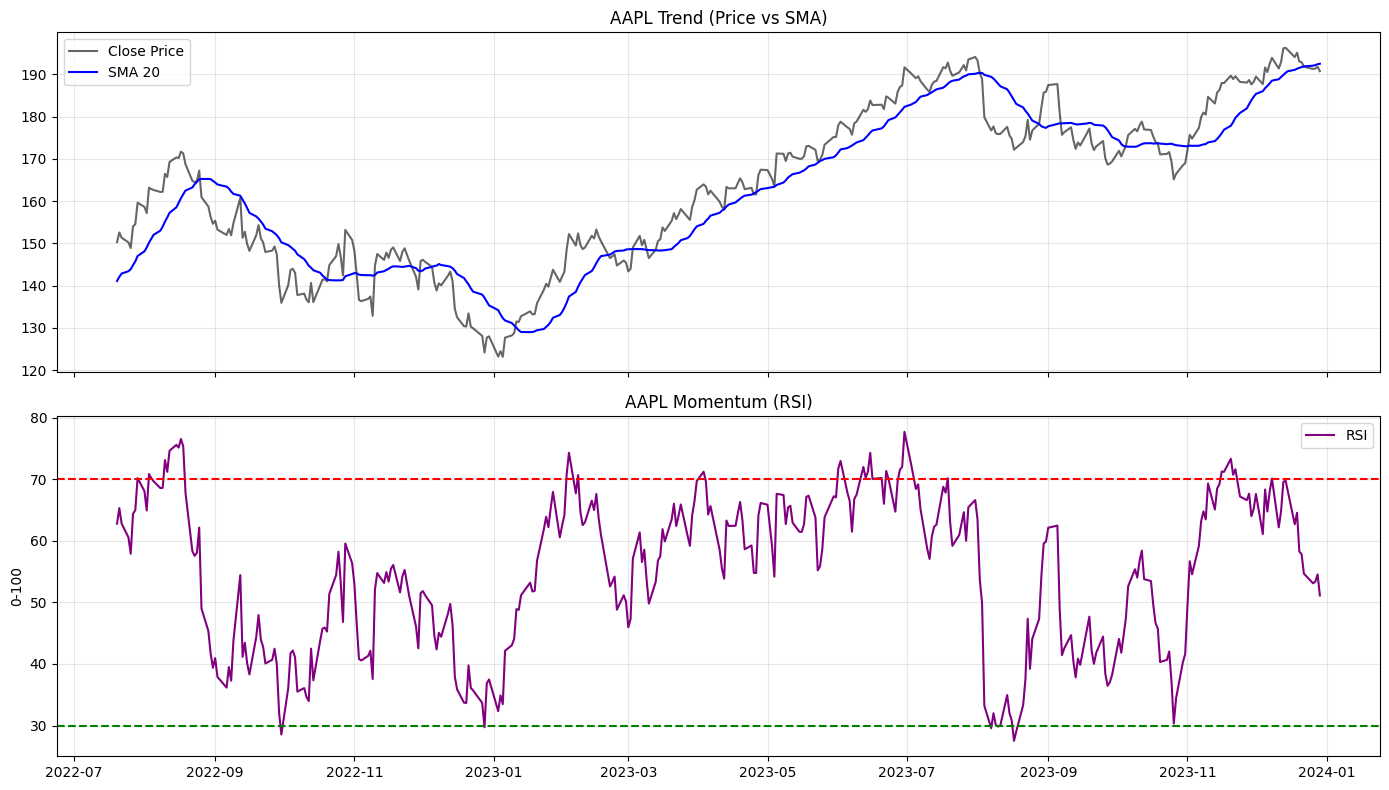

In [22]:
# Filter for AAPL to verify the math visually
plot_data = stock_df_analyzed[stock_df_analyzed["stock"] == "AAPL"].tail(365)

# Create the Dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Chart 1: Price vs SMA
ax1.plot(
    plot_data["date"], plot_data["close"], label="Close Price", color="black", alpha=0.6
)
ax1.plot(plot_data["date"], plot_data["SMA_20"], label="SMA 20", color="blue")
ax1.set_title("AAPL Trend (Price vs SMA)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: RSI
ax2.plot(plot_data["date"], plot_data["RSI"], label="RSI", color="purple")
ax2.axhline(70, color="red", linestyle="--")  # Overbought
ax2.axhline(30, color="green", linestyle="--")  # Oversold
ax2.set_title("AAPL Momentum (RSI)")
ax2.set_ylabel("0-100")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()